<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/Tarea_de_practica_en_clase_chunk_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Contexto Inicial
Copia este bloque de código para preparar el entorno con los datos originales

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Generación de Dataset Extendido (100 Clientes)
np.random.seed(42)
df = pd.DataFrame({
    "Ingresos": np.random.normal(30000, 12000, 100),
    "Edad": np.random.randint(18, 70, 100),
    "Altura": np.random.normal(1.70, 0.10, 100)
}, index=[f"P{i}" for i in range(1, 101)])

# Aseguramos que no haya ingresos negativos por la distribución normal
df["Ingresos"] = df["Ingresos"].clip(lower=1200)

print(f"Dataset listo con {len(df)} registros.")
df.head()

Dataset listo con 100 registros.


,Ingresos,Edad,Altura
P1,35960.569836,26,1.829940
P2,28340.828386,54,1.613285
P3,37772.262457,50,1.761764
P4,48276.358277,68,1.821707
P5,27190.159503,59,1.722629


Reto 1: El "Engaño" de la Distancia Cruda

Instrucciones: 1. Calcula la distancia euclidiana entre P1 y P5 usando los datos sin escalar.
2. Calcula la distancia entre P1 y P2.
3. Responde en el código: ¿Cuál está más "cerca" de P1 y qué variable determinó ese resultado?.

Pista: Usa np.linalg.norm(df.loc['P1'] - df.loc['P5']).

In [ ]:
# Tú código aquí
dist_P1_P5 = np.linalg.norm(df.loc['P1'] - df.loc['P5'])
dist_P1_P2 = np.linalg.norm(df.loc['P1'] - df.loc['P2'])
print(f"Distancia de P1 A P5 {dist_P1_P5}")
print(f"Distancia de P1 A P2 {dist_P1_P2}")
print(f"La distancia más cercana es de P1 a P2")
print(f"La variable que determino el resultado fue la de los ingresos")

Distancia de P1 A P5 8770.472417005858
Distancia de P1 A P2 7619.792898410529
La distancia más cercana es de P1 a P2
La variable que determino el resultado fue la de los ingresos


**Reto 2: Implementación del "Filtro de Rareza"
Instrucciones:**

* Aplica StandardScaler a todo el DataFrame.

* Crea un nuevo DataFrame llamado df_scaled que conserve los nombres de las columnas y los índices (P1, P2, etc.).

* Repite el cálculo de distancias del Reto 1 pero ahora usando df_scaled.

*Análisis: ¿El vecino más cercano sigue siendo el mismo? ¿Por qué?.*

In [ ]:
# Tú código aquí
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

labels = df.index.tolist()

X = df.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=df.columns, index=labels)

dist_P1_P5_v1 = np.linalg.norm(df_scaled.loc['P1'] - df_scaled.loc['P5'])
dist_P1_P2_v1 = np.linalg.norm(df_scaled.loc['P1'] - df_scaled.loc['P2'])
print(f"Distancia de P1 A P5 {dist_P1_P5_v1}")
print(f"Distancia de P1 A P2 {dist_P1_P2_v1}")
print("El vecino más cercano ahora es P5")

Distancia de P1 A P5 2.4914830841565485
Distancia de P1 A P2 2.970649874066311
El vecino más cercano ahora es P5


**Reto 3: Visualización de la "Deformación" del Espacio**

Instrucciones:Crea una figura con dos subgráficos (plt.subplots(1, 2)):

- Lado A (Sin escalar): Un scatter plot de "Ingresos" vs "Edad" donde se vea la enorme disparidad de los ejes.

- Lado B (Escalado): Un scatter plot de las mismas variables tras el StandardScaler.

- Extra: Dibuja una línea punteada que conecte a P1 con su vecino más cercano en ambos gráficos para ver cómo cambia la "dirección" de la cercanía.

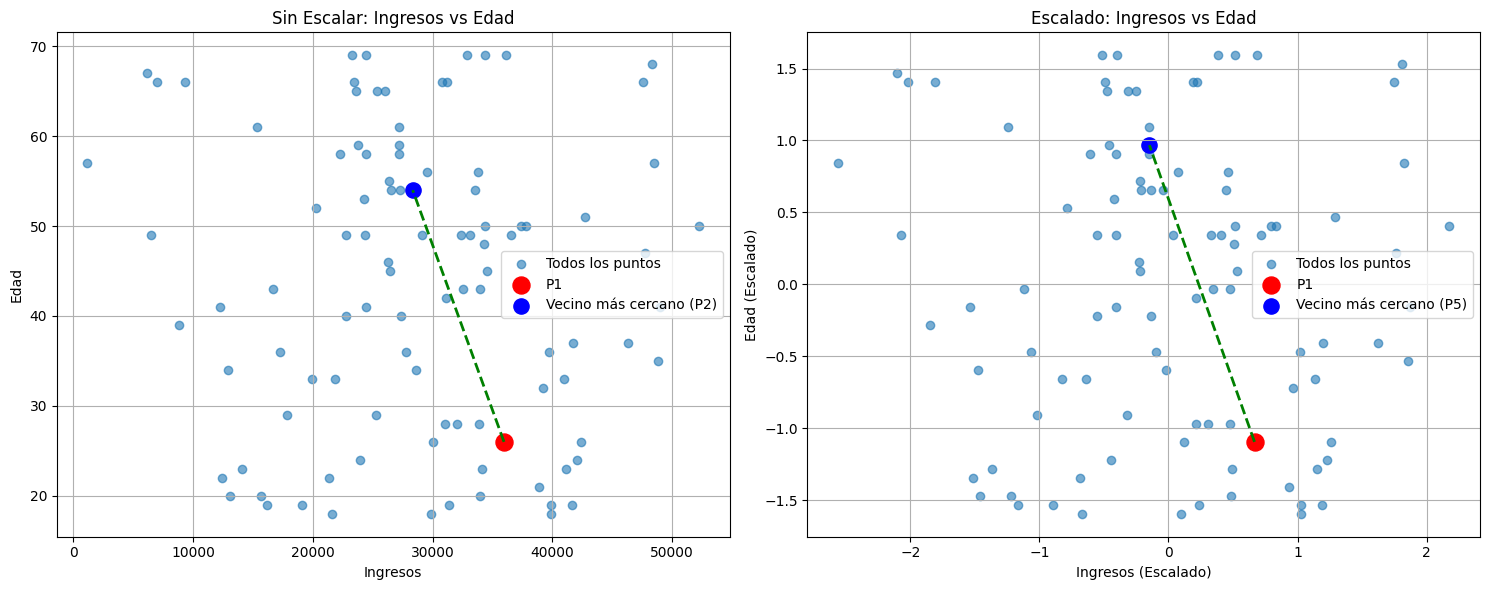

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Identificar el vecino más cercano para P1 en datos sin escalar (de Reto 1)
# P2 fue el más cercano a P1 en datos sin escalar (dist_P1_P2 = 7619.79, dist_P1_P5 = 8770.47)
closest_unscaled = 'P2'

# Identificar el vecino más cercano para P1 en datos escalados (de Reto 2)
# P5 fue el más cercano a P1 en datos escalados (dist_P1_P5_v1 = 2.49, dist_P1_P2_v1 = 2.97)
closest_scaled = 'P5'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Lado A: Sin escalar ---
axes[0].scatter(df['Ingresos'], df['Edad'], alpha=0.6, label='Todos los puntos')
axes[0].scatter(df.loc['P1', 'Ingresos'], df.loc['P1', 'Edad'], color='red', s=150, label='P1')
axes[0].scatter(df.loc[closest_unscaled, 'Ingresos'], df.loc[closest_unscaled, 'Edad'], color='blue', s=120, label=f'Vecino más cercano ({closest_unscaled})')
axes[0].plot([df.loc['P1', 'Ingresos'], df.loc[closest_unscaled, 'Ingresos']],
             [df.loc['P1', 'Edad'], df.loc[closest_unscaled, 'Edad']],
             linestyle='--', color='green', linewidth=2)
axes[0].set_xlabel('Ingresos')
axes[0].set_ylabel('Edad')
axes[0].set_title('Sin Escalar: Ingresos vs Edad')
axes[0].legend()
axes[0].grid(True)

# --- Lado B: Escalado ---
axes[1].scatter(df_scaled['Ingresos'], df_scaled['Edad'], alpha=0.6, label='Todos los puntos')
axes[1].scatter(df_scaled.loc['P1', 'Ingresos'], df_scaled.loc['P1', 'Edad'], color='red', s=150, label='P1')
axes[1].scatter(df_scaled.loc[closest_scaled, 'Ingresos'], df_scaled.loc[closest_scaled, 'Edad'], color='blue', s=120, label=f'Vecino más cercano ({closest_scaled})')
axes[1].plot([df_scaled.loc['P1', 'Ingresos'], df_scaled.loc[closest_scaled, 'Ingresos']],
             [df_scaled.loc['P1', 'Edad'], df_scaled.loc[closest_scaled, 'Edad']],
             linestyle='--', color='green', linewidth=2)
axes[1].set_xlabel('Ingresos (Escalado)')
axes[1].set_ylabel('Edad (Escalado)')
axes[1].set_title('Escalado: Ingresos vs Edad')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Agrega aquí tus conclusiones finales

En el gráfico sin escalar se observa que el eje de Ingresos domina completamente la visualización, ya que sus valores son mucho mayores que los de Edad. Por eso, la cercanía entre puntos está fuertemente influida por Ingresos.

En el gráfico escalado, ambas variables quedan en una escala comparable,
lo que permite observar mejor la distribución de los datos y cambia la dirección de la cercanía entre P1 y su vecino más próximo.

Esto demuestra que el escalado modifica la geometría del espacio de datos haciendo que la distancia euclidiana sea más justa entre variables con magnitudes distintas.